# [SK 05 - AssistantAPI AGENT with AzureAssistantAgent (kernel AND plugin)](https://learn.microsoft.com/en-us/semantic-kernel/frameworks/agent/assistant-agent?pivots=programming-language-python)
## e.g. from `ChatCompletionAgent` to `AzureAssistantAgent` (or `OpenAIAssistantAgent`)
- Chat Completion API focuses on simple conversational exchanges
- Assistant API allows for dynamic, goal-driven interactions with additional features like code-interpreter and file-search

[Samples](https://github.com/microsoft/semantic-kernel/tree/main/python/samples/getting_started_with_agents)

# [Migration guide](https://learn.microsoft.com/en-us/semantic-kernel/support/migration/agent-framework-rc-migration-guide?pivots=programming-language-python)
### **Semantic Kernel** `ChatCompletionAgent` vs **(Azure) OpenAI** `AzureAssistantAgent` / `OpenAIAssistantAgent`
Here we show how to create an **OpenAI Assistant** using Azure OpenAI, but may do the same thing with the "pure" OpenAI service.<br/>
Regardless of the framework used (Semantic Kernel in this case), the `AzureAssistantAgent` as well as `OpenAIAssistantAgent` are **OpenAI Assistants**, which allow for **function calling**, the use of **file search** and a **code interpreter**.<br/>
Assistant **Threads** are used to manage the **conversation state**, similar to a Semantic Kernel Chat History but hosted on the service side, and automatically managed by the OpenAI service.
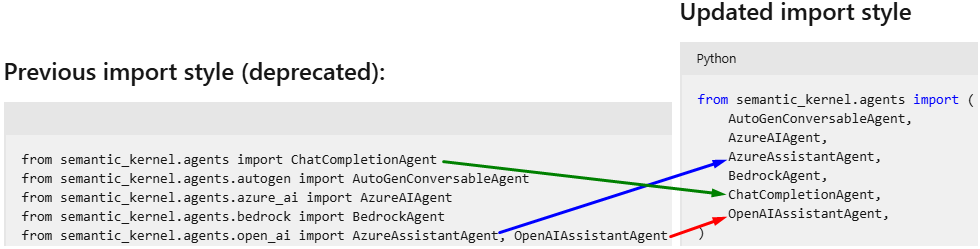

# Constants and Libraries

In [1]:
import os
from dotenv import load_dotenv # requires python-dotenv

load_dotenv("./../config/credentials_my.env")

agent_name                  = "mauromi_assistant_agent_python"
chatcompletion_service_id   = "chatcompletion_service_id"
instructions                = "you are a clever agent"
content                     = "Toggle the status of my second light."
plugin_name                 = "Lights"

print(f"os.environ['AZURE_OPENAI_ENDPOINT']: {os.environ['AZURE_OPENAI_ENDPOINT']}")

os.environ['AZURE_OPENAI_ENDPOINT']: https://mmoaiswc-01.openai.azure.com/


# Set the logging level for  semantic_kernel.kernel to DEBUG
One of the main benefits of using Semantic Kernel is that it supports enterprise-grade services.<br/>
In this sample, we add the logging service to the kernel to help debug the AI agent.

In [2]:
import logging

logging.basicConfig(
    format="[%(asctime)s - %(name)s:%(lineno)d - %(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S")
    
logging.getLogger("kernel").setLevel(logging.DEBUG)

# [Creating an Assistant Agent](https://learn.microsoft.com/en-us/semantic-kernel/support/migration/agent-framework-rc-migration-guide?pivots=programming-language-python#1-creating-an-assistant) requires the following steps:

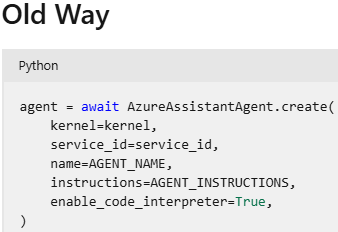 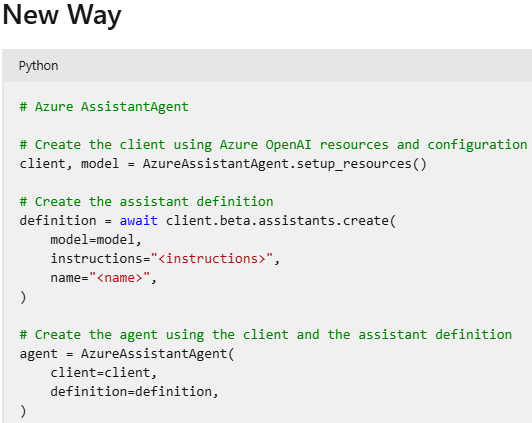<br/>
1. Setting up resources: client + model
2. Creating the assistant definition, using client + model created in the previous step
3. Creating the pre-requisites

## 1. [Setting up Resources: client + model](https://learn.microsoft.com/en-us/semantic-kernel/support/migration/agent-framework-rc-migration-guide?pivots=programming-language-python#setting-up-resources)
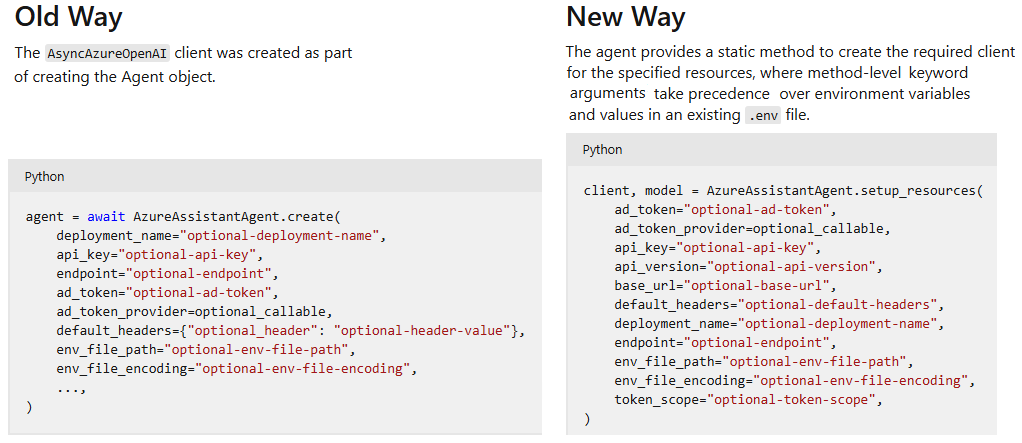

In [3]:
from semantic_kernel.agents import AzureAssistantAgent
from semantic_kernel.functions.kernel_arguments import KernelArguments

client, model = AzureAssistantAgent.setup_resources()

print(f"client.base_url: {client.base_url}, model: {model}")

client.base_url: https://mmoaiswc-01.openai.azure.com/openai/, model: gpt-4o


## 2. Creating the assistant definition, using client + model created in the previous step

In [4]:
definition = await client.beta.assistants.create(
    model=model,
    instructions=instructions,
    name=agent_name,    
)

definition

Assistant(id='asst_e6QHujTsoyt3pEuJoqOqwEEy', created_at=1743436627, description=None, instructions='you are a clever agent', metadata={}, model='gpt-4o', name='mauromi_assistant_agent_python', object='assistant', tools=[], response_format='auto', temperature=1.0, tool_resources=ToolResources(code_interpreter=None, file_search=None), top_p=1.0)

## 3. Secure the pre-requisites
- 3.1 Plugin definition
- 3.2 Create and add Prompt execution settings to the kernel

### 3.1 Plugin definition

In [5]:
# First, we define the plugin through its class...

class LightsPlugin:
    from typing import Annotated
    from semantic_kernel.functions import kernel_function
    
    lights = [
        {"id": 0, "name": "Table Lamp", "is_on": False},
        {"id": 1, "name": "Porch light", "is_on": False},
        {"id": 2, "name": "Chandelier", "is_on": False},
    ]

    @kernel_function(
        name="get_lights", # <<<=== DIFFERENT FROM THE FUNCTION NAME <get_state>, which will be ignored
        description="Gets a list of lights and their current state",
    )
    def get_state(
        self,
    ) -> Annotated[str, "the output is a string"]:
        """Gets a list of lights and their current state."""
        return self.lights

    @kernel_function(
        name="change_state",
        description="Changes the state of the light",
    )
    def change_state(
        self,
        id: int,
        is_on: bool,
    ) -> Annotated[str, "the output is a string"]:
        """Changes the state of the light."""
        for light in self.lights:
            if light["id"] == id:
                light["is_on"] = is_on
                return light
        return None

### 3.2 Prompt execution settings (enable planning for function calling)

In [6]:
from semantic_kernel.connectors.ai.open_ai.prompt_execution_settings.azure_chat_prompt_execution_settings import AzureChatPromptExecutionSettings
from semantic_kernel.connectors.ai.function_choice_behavior import FunctionChoiceBehavior # Auto(), Required() or NoneInvoke()

execution_settings = AzureChatPromptExecutionSettings()
execution_settings.function_choice_behavior= FunctionChoiceBehavior.Auto() # Auto(), Required() or NoneInvoke()
execution_settings

AzureChatPromptExecutionSettings(service_id=None, extension_data={}, function_choice_behavior=FunctionChoiceBehavior(enable_kernel_functions=True, maximum_auto_invoke_attempts=5, filters=None, type_=<FunctionChoiceType.AUTO: 'auto'>), ai_model_id=None, frequency_penalty=None, logit_bias=None, max_tokens=None, number_of_responses=None, presence_penalty=None, seed=None, stop=None, stream=False, temperature=None, top_p=None, user=None, store=None, metadata=None, response_format=None, function_call=None, functions=None, messages=None, parallel_tool_calls=None, tools=None, tool_choice=None, structured_json_response=False, stream_options=None, max_completion_tokens=None, reasoning_effort=None, extra_body=None)

# 4. Create the Assistant Agent on Azure (AzureAssistantAgent)
**Possible bug**: Make sure that the constant value for DEFAULT_AZURE_API_VERSION in `envs\<semantic_kernel_env_name>\Lib\site-packages\semantic_kernel\connectors\ai\open_ai\const.py` matches your `OPENAI_API_VERSION` environment value (listed for example in credentials_my.env).

In [7]:
agent = AzureAssistantAgent(
    client=client,
    definition=definition,
    plugins=[LightsPlugin()],
    arguments=KernelArguments(settings=execution_settings)
)

agent

AzureAssistantAgent(arguments={}, description=None, id='asst_e6QHujTsoyt3pEuJoqOqwEEy', instructions='you are a clever agent', kernel=Kernel(retry_mechanism=PassThroughWithoutRetry(), services={}, ai_service_selector=<semantic_kernel.services.ai_service_selector.AIServiceSelector object at 0x0000019935DE97F0>, plugins={'LightsPlugin': KernelPlugin(name='LightsPlugin', description=None, functions={'change_state': KernelFunctionFromMethod(metadata=KernelFunctionMetadata(name='change_state', plugin_name='LightsPlugin', description='Changes the state of the light', parameters=[KernelParameterMetadata(name='id', description=None, default_value=None, type_='int', is_required=True, type_object=<class 'int'>, schema_data={'type': 'integer'}, include_in_function_choices=True), KernelParameterMetadata(name='is_on', description=None, default_value=None, type_='bool', is_required=True, type_object=<class 'bool'>, schema_data={'type': 'boolean'}, include_in_function_choices=True)], is_prompt=False,

# [Invoke the Agent using a thread](https://learn.microsoft.com/en-us/semantic-kernel/support/migration/agent-framework-rc-migration-guide?pivots=programming-language-python#2-creating-a-thread)
As of Semantic Kernel Python 1.26.0 and later, we introduced a new common abstraction to manage threads for all agents. For each agent we now expose a thread class that implements the `AgentThread` base class, allowing context management via methods like create() and delete().

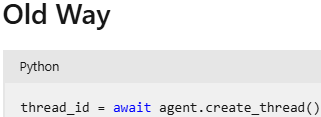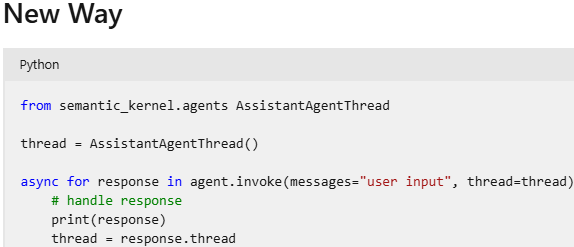

In [8]:
from semantic_kernel.agents import AssistantAgentThread

thread = AssistantAgentThread(client=client)

async for response in agent.invoke(messages=content, thread=thread):
    # handle response
    print(f"\nRESPONSE: {response}")
    thread = response.thread
    # await print_messages(thread=thread)


RESPONSE: The status of your second light, the Porch light, has been toggled to 'on'.


In [9]:
follow_up_question = "Toggle the first light and give me the status of all my lights."

async for response in agent.invoke(messages=follow_up_question, thread=thread):
    # handle response
    print(f"\nRESPONSE: {response}")
    thread = response.thread
    # await print_messages(thread=thread)


RESPONSE: The status of your lights is as follows:

1. **Table Lamp**: On
2. **Porch light**: On
3. **Chandelier**: Off

The Table Lamp has been toggled to 'on'.


In [10]:
messages = [message async for message in thread.get_messages()]
messages

[ChatMessageContent(inner_content=None, ai_model_id=None, metadata={}, content_type='message', role=<AuthorRole.ASSISTANT: 'assistant'>, name='msg_dr6RywhSMqtxDYvlscStVaho', items=[TextContent(inner_content=None, ai_model_id=None, metadata={}, content_type='text', text="The status of your lights is as follows:\n\n1. **Table Lamp**: On\n2. **Porch light**: On\n3. **Chandelier**: Off\n\nThe Table Lamp has been toggled to 'on'.", encoding=None)], encoding=None, finish_reason=None),
 ChatMessageContent(inner_content=None, ai_model_id=None, metadata={}, content_type='message', role=<AuthorRole.ASSISTANT: 'assistant'>, name='mauromi_assistant_agent_python', items=[TextContent(inner_content=None, ai_model_id=None, metadata={}, content_type='text', text="The status of your lights is as follows:\n\n1. **Table Lamp**: On\n2. **Porch light**: On\n3. **Chandelier**: Off\n\nThe Table Lamp has been toggled to 'on'.", encoding=None)], encoding=None, finish_reason=None),
 ChatMessageContent(inner_cont

# TEARDOWN

In [11]:
# delete files

async def print_files(client):
    files_list = await client.files.list()
    i = 0
    async for file in files_list:
        i += 1
        print(f"File {i}: {file.filename} (id={file.id}) is being deleted...")
        client.files.delete(file.id)

# Call the async function directly in a Jupyter Notebook cell
await print_files(client)

In [12]:
# delete thread
print(f"Deleting thread {thread.id}...")
await thread.delete()

Deleting thread thread_pHSV02AJEI3Pw3vM9eMwXQTv...


In [13]:
# delete all assistant agents

assistants_list = (await client.beta.assistants.list()).data
print(f"There are {len(assistants_list)} assistants to delete")

i = 0
for assistant in assistants_list:
    i += 1
    print(f"Assistant {i}/{len(assistants_list)}: Assistant {assistant.name} ({assistant.id})) is being deleted...")
    await client.beta.assistants.delete(assistant_id=assistant.id) # comment / un-comment this line if you want to delete it

There are 1 assistants to delete
Assistant 1/1: Assistant mauromi_assistant_agent_python (asst_e6QHujTsoyt3pEuJoqOqwEEy)) is being deleted...
